# Week 6: Human Activity Classification 고도화 (2026-05-07)

## 1. 환경 설정 및 데이터 로드

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import math
import datetime as dt
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
import xlrd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier, VotingRegressor, StackingClassifier, StackingRegressor, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, r2_score, mean_absolute_error, precision_recall_curve, recall_score, f1_score, silhouette_samples, silhouette_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.datasets import load_iris, make_blobs
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.mixture import GaussianMixture
from config import CONTENT_DIR

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'NanumGothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False

   sepal_length  sepal_width  petal_length  petal_width  target
0           5.1          3.5           1.4          0.2       0
1           4.9          3.0           1.4          0.2       0
2           4.7          3.2           1.3          0.2       0
3           4.6          3.1           1.5          0.2       0
4           5.0          3.6           1.4          0.2       0


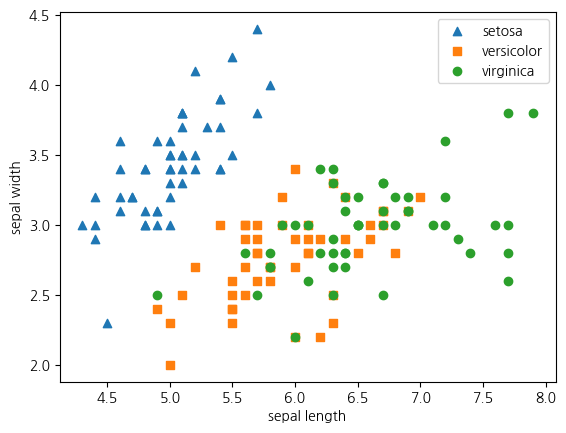

   pca_component_1  pca_component_2  target
0        -2.264703         0.480027       0
1        -2.080961        -0.674134       0
2        -2.364229        -0.341908       0
3        -2.299384        -0.597395       0
4        -2.389842         0.646835       0
[0.72962445 0.22850762]


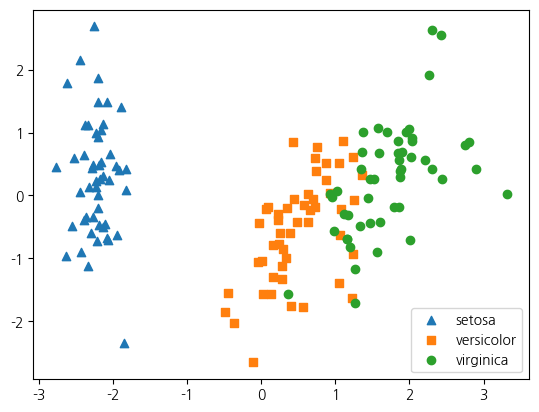

원본 데이터 교차 검증 개별 정확도: [0.98 0.94 0.98]
원본 데이터 평균 정확도: 0.9666666666666667
PCA 변환 데이터 교차 검증 개별 정확도: [0.88 0.88 0.88]
PCA 변환 데이터 평균 정확도: 0.88


In [ ]:
# 사이킷런 내장 데이터 셋 iris api 호출
iris_data = load_iris()

columns = ['sepal_length','sepal_width', 'petal_length', 'petal_width']
iris_df = pd.DataFrame(iris_data.data, columns=columns)
iris_df['target'] = iris_data.target

print(iris_df.head())
# setosa는 세모, versicolor는 네모, virginica는 동그라미
marker = ['^', 's', 'o']

for i, marker in enumerate(marker):
    x_data = iris_df[iris_data.target==i]['sepal_length']
    y_data = iris_df[iris_data.target==i]['sepal_width']
    plt.scatter(x_data, y_data, marker=marker, label=iris_data.target_names[i])

plt.legend()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.show()

# Target값을 제외한 모든 속성 값을 StandardScaler를 이용해서 표준 정규 분포를 가지는 값들로 변환
# 평균 0, 표준편차 1
scaler = StandardScaler()
scaler.fit(iris_df.iloc[:,:-1]) 
iris_scaled = scaler.transform(iris_df.iloc[:,:-1])

pca = PCA(n_components=2)

pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)

irispca_df = pd.DataFrame(iris_pca, columns=['pca_component_1', 'pca_component_2'])
irispca_df['target'] = iris_data.target
print(irispca_df.head())

#각 주성분이 차지하는 설명력 비중
print(pca.explained_variance_ratio_) 

# setosa : 세모, versicolor는 네모, virginica는 동그라미
marker = ['^', 's', 'o']

for i, marker in enumerate(marker):
    x_data = irispca_df[irispca_df.target==i]['pca_component_1']
    y_data = irispca_df[irispca_df.target==i]['pca_component_2']
    plt.scatter(x_data, y_data, marker=marker, label=iris_data.target_names[i])

plt.legend()
plt.xlabel('')
plt.ylabel('')
plt.show()

rfc = RandomForestClassifier(random_state=1)
scores = cross_val_score(rfc, iris_data.data, iris_data.target, scoring='accuracy', cv=3)

print('원본 데이터 교차 검증 개별 정확도:', scores)
print('원본 데이터 평균 정확도:', np.mean(scores))

pca_X = irispca_df[['pca_component_1', 'pca_component_2']]
scores_pca = cross_val_score(rfc, pca_X, iris_data.target, scoring='accuracy', cv=3 )

print('PCA 변환 데이터 교차 검증 개별 정확도:', scores_pca)
print('PCA 변환 데이터 평균 정확도:', np.mean(scores_pca))

   lda_component_1  lda_component_2  target
0         8.061800        -0.300421       0
1         7.128688         0.786660       0
2         7.489828         0.265384       0
3         6.813201         0.670631       0
4         8.132309        -0.514463       0
[0.9912126 0.0087874]


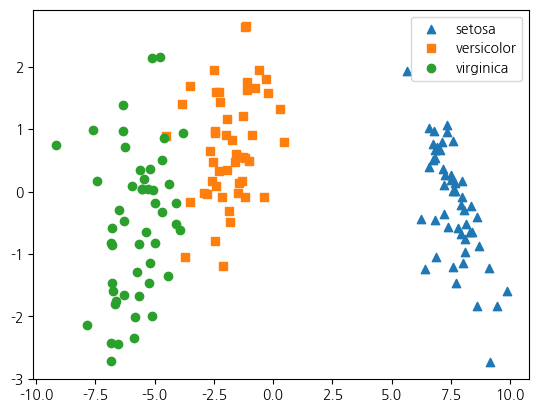

lda 변환 데이터 교차 검증 개별 정확도: [1.   0.92 0.94]
lda 변환 데이터 평균 정확도: 0.9533333333333333


In [27]:
lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(iris_scaled, iris_data.target)
iris_lda = lda.transform(iris_scaled)

irislda_df = pd.DataFrame(iris_lda, columns=['lda_component_1', 'lda_component_2'])
irislda_df['target'] = iris_data.target
print(irislda_df.head())

#각 주성분이 차지하는 설명력 비중
print(lda.explained_variance_ratio_) 

# setosa : 세모, versicolor는 네모, virginica는 동그라미
marker = ['^', 's', 'o']

for i, marker in enumerate(marker):
    x_data = irislda_df[irislda_df.target==i]['lda_component_1']
    y_data = irislda_df[irislda_df.target==i]['lda_component_2']
    plt.scatter(x_data, y_data, marker=marker, label=iris_data.target_names[i])

plt.legend()
plt.xlabel('')
plt.ylabel('')
plt.show()

lda_X = irislda_df[['lda_component_1', 'lda_component_2']]
scores_lda = cross_val_score(rfc, lda_X, iris_data.target, scoring='accuracy', cv=3 )

print('lda 변환 데이터 교차 검증 개별 정확도:', scores_lda)
print('lda 변환 데이터 평균 정확도:', np.mean(scores_lda))

   tsvd_component_1  tsvd_component_2  target
0         -2.264703          0.480027       0
1         -2.080961         -0.674134       0
2         -2.364229         -0.341908       0
3         -2.299384         -0.597395       0
4         -2.389842          0.646835       0
[0.72962445 0.22850762]


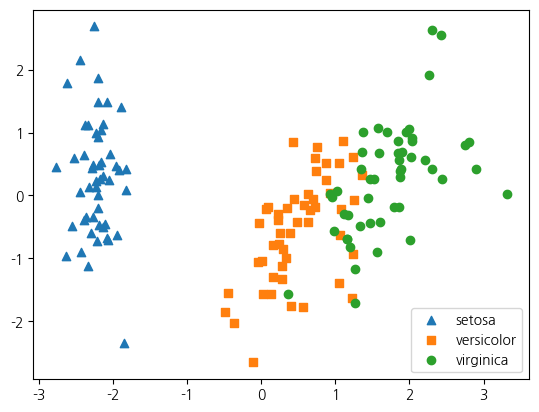

tsvd 변환 데이터 교차 검증 개별 정확도: [0.88 0.88 0.88]
tsvd 변환 데이터 평균 정확도: 0.88


In [30]:
tsvd = TruncatedSVD(n_components=2)
tsvd.fit(iris_scaled)
iris_tsvd = tsvd.transform(iris_scaled)

iristsvd_df = pd.DataFrame(iris_tsvd, columns=['tsvd_component_1', 'tsvd_component_2'])
iristsvd_df['target'] = iris_data.target
print(iristsvd_df.head())

#각 주성분이 차지하는 설명력 비중
print(tsvd.explained_variance_ratio_) 

# setosa : 세모, versicolor는 네모, virginica는 동그라미
marker = ['^', 's', 'o']

for i, marker in enumerate(marker):
    x_data = iristsvd_df[iristsvd_df.target==i]['tsvd_component_1']
    y_data = iristsvd_df[iristsvd_df.target==i]['tsvd_component_2']
    plt.scatter(x_data, y_data, marker=marker, label=iris_data.target_names[i])

plt.legend()
plt.xlabel('')
plt.ylabel('')
plt.show()

tsvd_X = iristsvd_df[['tsvd_component_1', 'tsvd_component_2']]
scores_tsvd = cross_val_score(rfc, tsvd_X, iris_data.target, scoring='accuracy', cv=3 )

print('tsvd 변환 데이터 교차 검증 개별 정확도:', scores_tsvd)
print('tsvd 변환 데이터 평균 정확도:', np.mean(scores_tsvd))

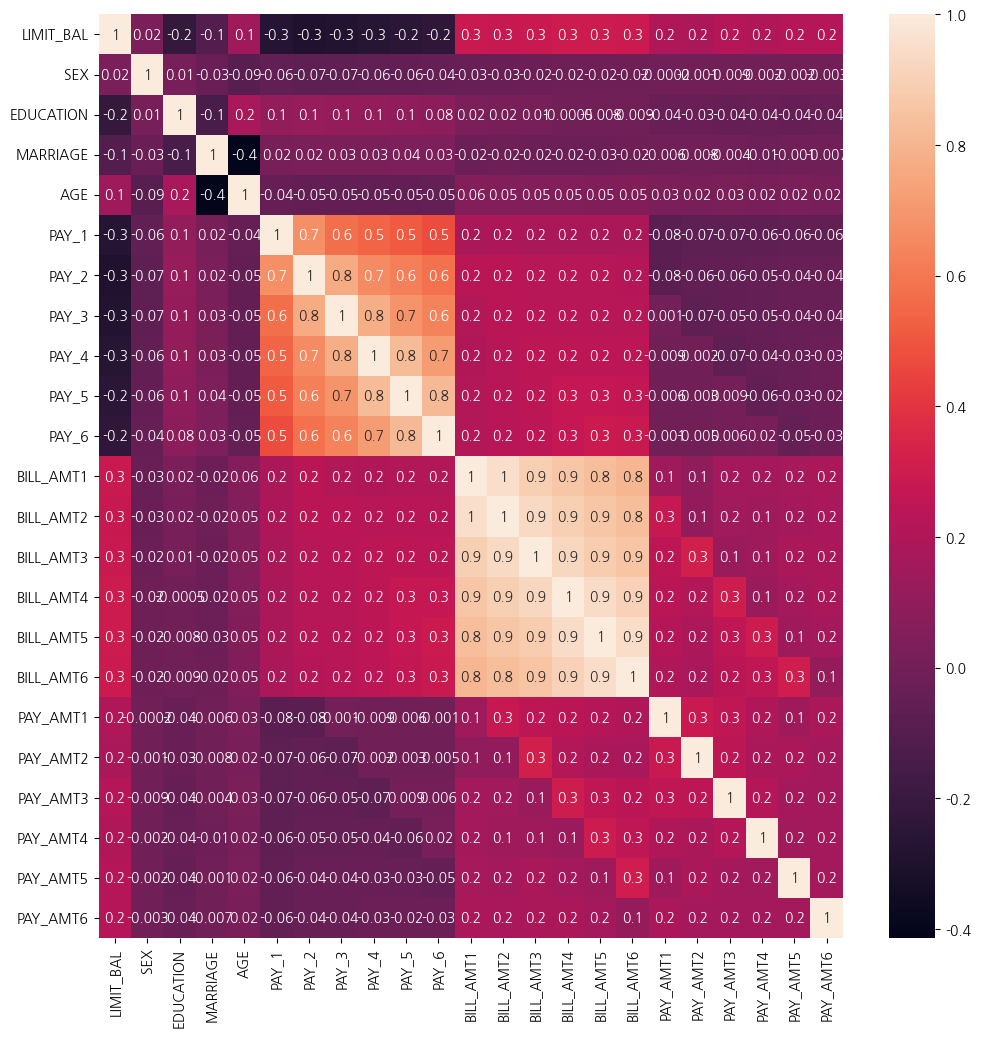

[0.90555253 0.0509867 ]
원본 데이터 교차 검증 개별 정확도: [0.8063 0.8197 0.8232]
원본 데이터 평균 정확도: 0.8163999999999999
PCA 변환 데이터 교차 검증 개별 정확도: [0.7436 0.752  0.7495]
PCA 변환 데이터 평균 정확도: 0.7483666666666666


In [ ]:
df = pd.read_excel(f'{CONTENT_DIR}/pca_credit_card.xls', header=1, sheet_name='Data')
df.drop('ID', axis=1, inplace=True)
df.rename(columns={'PAY_0':'PAY_1', 'default payment next month':'default'}, inplace=True)

X_data = df.drop('default', axis=1)
y_data = df['default']

corr = X_data.corr()

plt.figure(figsize=(12,12))
sns.heatmap(
    corr, 
    annot=True,     # annot=True: 각 셀에 상관계수 값 표시
    fmt='.1g'       # fmt='.1g': 소수점 첫째자리까지 표시
    )
plt.show()

X = df.drop('default', axis=1)
y = df['default']

scaler = StandardScaler()
scaler.fit(X.iloc[:,11:17])
X_scaled = scaler.transform(X.iloc[:,11:17])

pca = PCA(n_components=2)

pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

print(pca.explained_variance_ratio_) 

rfc = RandomForestClassifier(random_state=1)
scores = cross_val_score(rfc, X, y, scoring='accuracy', cv=3)

print('원본 데이터 교차 검증 개별 정확도:', scores)
print('원본 데이터 평균 정확도:', np.mean(scores))

scores_pca = cross_val_score(rfc, X_pca, y, scoring='accuracy', cv=3 )

print('PCA 변환 데이터 교차 검증 개별 정확도:', scores_pca)
print('PCA 변환 데이터 평균 정확도:', np.mean(scores_pca))

In [42]:
X_others = X.drop(['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6'], axis=1)
X_combined = pd.concat([X_others, pd.DataFrame(X_pca, columns=['pca_1', 'pca_2'])], axis=1)

scores_pca = cross_val_score(rfc, X_combined, y, scoring='accuracy', cv=3 )

print('PCA 변환 데이터 교차 검증 개별 정확도:', scores_pca)
print('PCA 변환 데이터 평균 정확도:', np.mean(scores_pca))

PCA 변환 데이터 교차 검증 개별 정확도: [0.8097 0.8189 0.8216]
PCA 변환 데이터 평균 정확도: 0.8167333333333334


<Axes: xlabel='var_1', ylabel='var_2'>

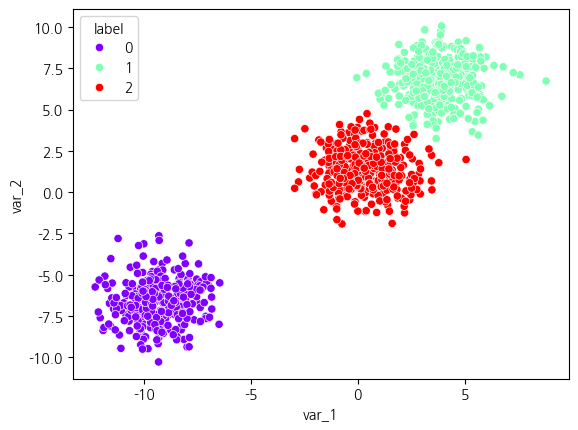

In [ ]:
df = pd.read_csv(f'{CONTENT_DIR}/example_cluster.csv')
model_kmeans = KMeans(n_clusters=3, random_state=1)
df['label'] = model_kmeans.fit_predict(df)

sns.scatterplot(x='var_1', 
                y='var_2',
                data=df,
                hue='label',
                palette='rainbow')

In [62]:
iris_data = load_iris()
iris_df = pd.DataFrame(data=iris_data.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

model_kmeans = KMeans(n_clusters=3,
                      random_state=1,
                      init='k-means++',         # 초기 중심점을 설정 방식. 가능하면 서로 떨어진 곳에 중심점을 잘 배치하자.
                      max_iter=300)             # 최대 반복 횟수 300(수렴하지 않을 경우 300번까지 반복)

model_kmeans.fit(iris_df)
iris_df['cluster'] = model_kmeans.labels_
iris_df['target'] = iris_data.target

iris_result = iris_df.groupby(['target', 'cluster'])['sepal_length'].count()
print(iris_result)

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


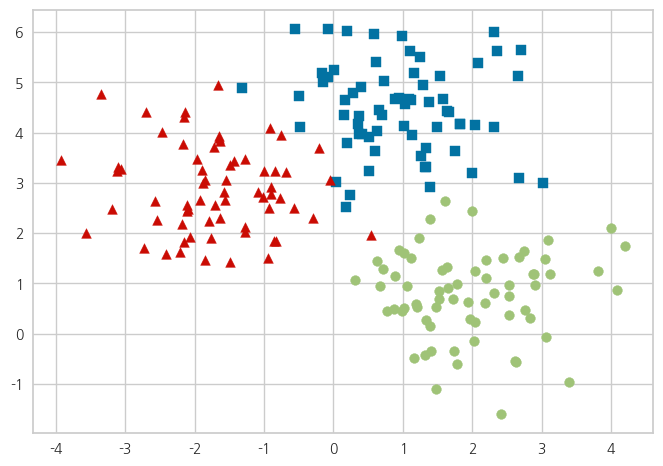

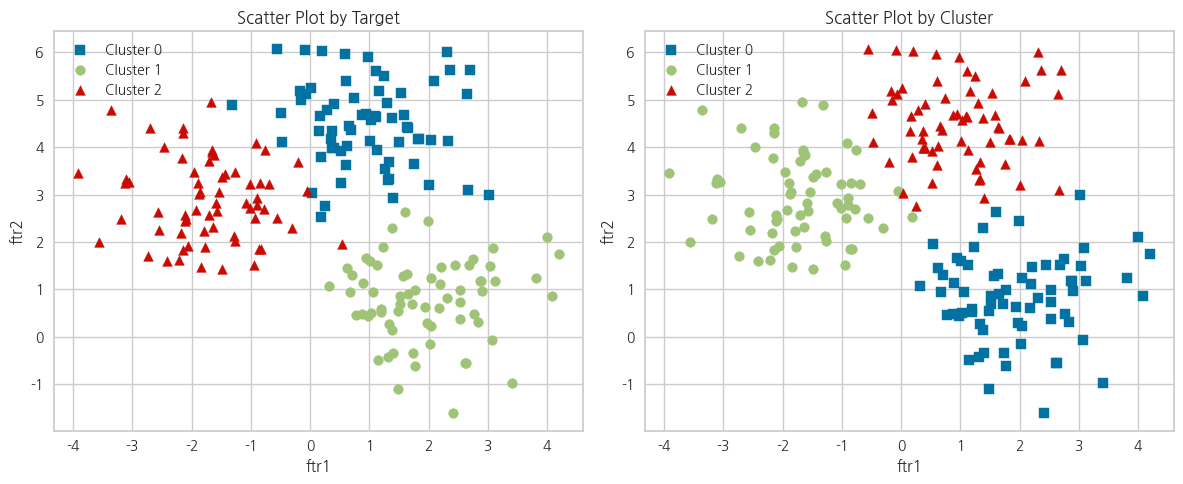

In [81]:
X, y = make_blobs(                          # make_blobs : 군집형 데이터를 생성하기 위한 함수                       
                  n_samples=200,            # 총 200개의 데이터 샘플 생성
                  n_features=2,             # 2개의 특성(2차원 좌표 형태)
                  centers=3,                # 3개의 클러스터 중심을 생성
                  cluster_std=0.9,          # 각 클러스터의 표준편차 0.9(값이 클수록 데이터가 더 넓게 퍼짐)
                  shuffle=True,             
                  random_state=0)

cluster_df = pd.DataFrame(data=X,
                          columns=['ftr1', 'ftr2'])
cluster_df['target'] = y

model_kmeans.fit(cluster_df.drop('target', axis=1))
cluster_df['cluster'] = model_kmeans.labels_

# 시각화
marker0 = cluster_df[cluster_df['target']==0].index
marker1 = cluster_df[cluster_df['target']==1].index
marker2 = cluster_df[cluster_df['target']==2].index

plt.scatter(x=cluster_df.loc[marker0,'ftr1'], y=cluster_df.loc[marker0,'ftr2'], marker='s') # 사각형
plt.scatter(x=cluster_df.loc[marker1,'ftr1'], y=cluster_df.loc[marker1,'ftr2'], marker='o') # 원형
plt.scatter(x=cluster_df.loc[marker2,'ftr1'], y=cluster_df.loc[marker2,'ftr2'], marker='^') # 삼각형

plt.show()

# Subplots 생성 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 그래프에 필요한 설정값
titles = ['Scatter Plot by Target', 'Scatter Plot by Cluster']
columns = ['target', 'cluster']
markers = ['s', 'o', '^']
x_label = 'ftr1'
y_label = 'ftr2'

# 반복문으로 두 개의 서브플롯 생성
for i in range(2):
    for cluster_num in range(3):
        marker_index = cluster_df[cluster_df[columns[i]] == cluster_num].index
        axes[i].scatter(
            x=cluster_df.loc[marker_index, 'ftr1'],
            y=cluster_df.loc[marker_index, 'ftr2'],
            marker=markers[cluster_num],
            label=f'Cluster {cluster_num}'
        )
    axes[i].set_title(titles[i])
    axes[i].set_xlabel(x_label)
    axes[i].set_ylabel(y_label)
    axes[i].legend()

# 레이아웃 조정 및 그래프 출력
plt.tight_layout()
plt.show()


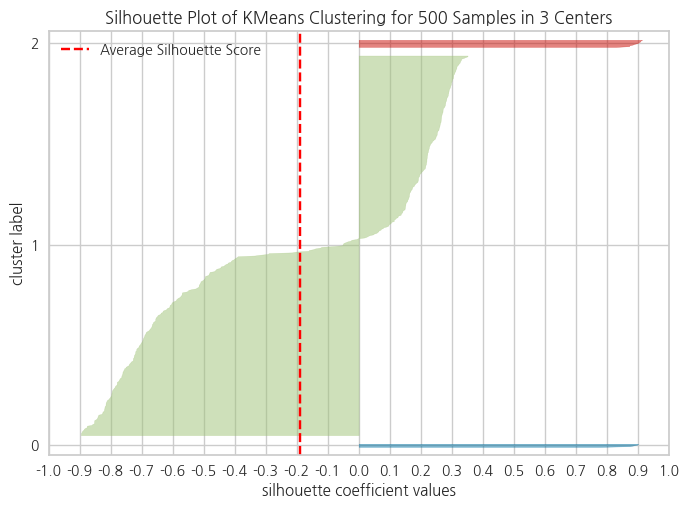

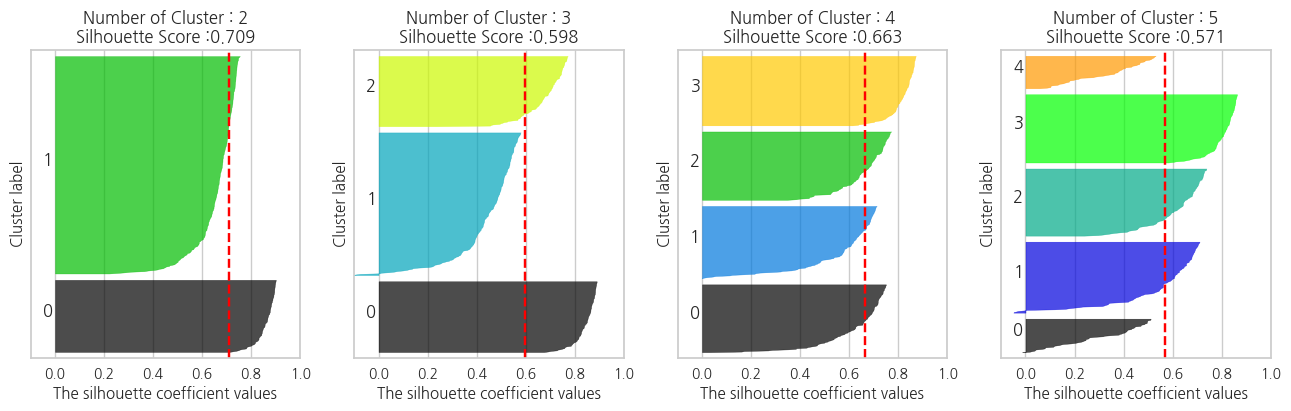

In [84]:
score_sample = silhouette_samples(iris_data.data, iris_df['cluster'])
iris_df['silhouette_coef'] = score_sample

visualize = SilhouetteVisualizer(model_kmeans, colors='yellowbrick', force_model=True)
visualize.fit(X)
visualize.show()

### 여러개의 클러스터링 갯수를 List로 입력 받아 각각의 실루엣 계수를 면적으로 시각화한 함수 작성
def visualize_silhouette(cluster_list, X_features):

    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_list)

    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_list):

        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산.
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        clusterer.fit(X_features)
        cluster_labels = clusterer.predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현.
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper),
                                   0,
                                   ith_cluster_sil_values,
                                   facecolor=color,
                                   edgecolor=color,
                                   alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

# make_blobs를 통해 군집화를 위한 4개의 군집 중심의 500개 2차원 데이터 세트 생성
X, y = make_blobs(n_samples=500, 
                  n_features=2, 
                  centers=4, 
                  cluster_std=1,
                  center_box=(-10.90, 10.0),
                  shuffle=True,
                  random_state=1)

# 군집의 개수가 2개, 3개, 4개, 5개 일 때의 군집별 실루엣 계수 평균값을 시각화
visualize_silhouette([2,3,4,5], X)

In [ ]:
iris_data = load_iris()
feature_names = ['sepal_length','sepal_width','petal_length','petal_width']

iris_df = pd.DataFrame(data=iris_data.data, columns=feature_names)
iris_df['target'] = iris_data.target

gmm = GaussianMixture(n_components=3, random_state=1)

iris_df['gmm_cluster'] = gmm.fit_predict(iris_data.data)

# iris의 모든 개별 데이터에 실루엣 계수 구하기
iris_df['gmm_silhouette_coef'] = silhouette_samples(iris_data.data, iris_df['gmm_cluster'])
gmm_avg_score = silhouette_score(iris_data.data, iris_df['gmm_cluster'])


kmeans = KMeans(n_clusters=3,
                init='k-means++',
                max_iter=300,
                random_state=1)
kmeans.fit(iris_data.data)
iris_df['kmeans_cluster'] = kmeans.labels_
iris_df['kmeans_silhouette_coef'] = silhouette_samples(iris_data.data, iris_df['kmeans_cluster'])

kmeans_cluster_avg_score = silhouette_score(iris_data.data, iris_df['kmeans_cluster'])

0.5511916046195919

In [ ]:
retail_df = pd.read_excel(f'{CONTENT_DIR}/Online Retail.xlsx')
retail_df = retail_df[retail_df['Quantity']>0]
retail_df = retail_df[retail_df['UnitPrice']>0]
retail_df = retail_df.dropna()
retail_df['sale_amount'] = retail_df['Quantity'] * retail_df['UnitPrice']
retail_df['CustomerID'] = retail_df['CustomerID'].astype('int')

In [ ]:
aggregation = {
    'sale_amount' : 'sum',      # M
    'InvoiceNo' : 'count',      # F
    'InvoiceDate' : 'max'       # R    
}

cust_df = retail_df.groupby('CustomerID').agg(aggregation)
cust_df['InvoiceDate'] = (dt.datetime(2011,12,10) - cust_df['InvoiceDate']).dt.days

scaled_data = StandardScaler().fit_transform(cust_df)

kmeans = KMeans(n_clusters=5, random_state=1)
kmeans.fit(scaled_data)

cust_df['cluster'] = kmeans.labels_

# 1. 로그 변환 (순서: R, F, M)
cust_df_log = np.log1p(cust_df[['InvoiceDate', 'InvoiceNo', 'sale_amount']])
# 2. 스케일링 및 KMeans
scaled_data_log = StandardScaler().fit_transform(cust_df_log)
kmeans_log = KMeans(n_clusters=5, random_state=1)
cust_df['cluster_log'] = kmeans_log.fit_predict(scaled_data_log)

# 3. 3D 시각화 (이상 없음)
fig = px.scatter_3d(cust_df, 
                    x='InvoiceDate', y='InvoiceNo', z='sale_amount',
                    color='cluster_log', 
                    title='RFM 3D cluster_log Visualization',
                    labels={'InvoiceDate':'Recency', 'InvoiceNo':'Frequency', 'sale_amount':'Monetary'},
                    opacity=0.6)
fig.show()
# 4. 스네이크 플롯 데이터 재구성 (라벨 순서 수정 ★)
# scaled_data_log의 순서인 R-F-M에 맞춰 컬럼명을 부여해야 합니다.
df_melt = pd.DataFrame(scaled_data_log, columns=['Recency', 'Frequency', 'Monetary']) # 수정됨
df_melt['cluster_log'] = kmeans_log.labels_
df_melt = df_melt.groupby('cluster_log').mean().reset_index()
# 데이터 재구성 (Melting)
df_melt = df_melt.melt(id_vars='cluster_log', var_name='Metric', value_name='Value')
# 시각화
fig = px.line(df_melt, x='Metric', y='Value', color='cluster_log', markers=True,
              title='Customer Segment Profiles (Snake Plot)')
fig.show()
# 5. 박스 플롯 (이상 없음)
fig = px.box(cust_df, x='cluster_log', y='sale_amount', points="all", title='Monetary Distribution by cluster_log')
fig.show()